# 6-Month Forecast — Flood & Flashflood
analysis 6-month forecast (Jun–Nov 2026) Tambon Level:
1. load forecast + clean tambon geojson
2. data check
3. check GEOCODE vs ADM3_PCODE — join key ตรงกันแค่ไหน
4. fix mismatch
5. analysis
   - option 1: risk level (Tambon level): `no risk` = 0 month, `low risk` = 1–2, `high risk` = 3–6
   - option 2: risk take max
6. output geojson แยก flood / flashflood → tableau

## Load data

In [44]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

FORECAST_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/Flood Forecast 6 month/202607FloodForecast_6month.xlsx')
SHAPE_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/TH_TAMBON_json/tha_admbnda_adm3_rtsd_20220121_geo.json')
OUTPUT_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean')

forecast = pd.read_excel(FORECAST_PATH)
shapes = gpd.read_file(SHAPE_PATH)

print('Forecast rows:', len(forecast))
print('Tambon polygons:', len(shapes))

Forecast rows: 44328
Tambon polygons: 7425


## Data check
- forecast: field

In [45]:
print('Columns:', list(forecast.columns))
print()
print('Rows per month:')
print(forecast['MONTH'].value_counts().sort_index().to_string())
print()
print('Unique tambons:', forecast['TAMBON_IDN'].nunique())
print()
print(forecast['TYPE_E'].value_counts().to_string())
forecast.head()

Columns: ['TAMBON_IDN', 'TAMBON_T', 'TAMBON_E', 'AMPHOE_IDN', 'AMPHOE_T', 'AMPHOE_E', 'PROV_CODE', 'PROV_T', 'PROV_E', 'REGION_CODE', 'REGION', 'TYPE_T', 'TYPE_E', 'YEAR', 'MONTH']

Rows per month:
MONTH
7     7388
8     7388
9     7388
10    7388
11    7388
12    7388

Unique tambons: 7387

TYPE_E
norisk        39850
flood risk     3689
flashflood      789


,TAMBON_IDN,TAMBON_T,TAMBON_E,AMPHOE_IDN,AMPHOE_T,AMPHOE_E,PROV_CODE,PROV_T,PROV_E,REGION_CODE,REGION,TYPE_T,TYPE_E,YEAR,MONTH
0,100101,แขวงพระบรมมหาราช,Phraborom Maharatchawang,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,7
1,100102,แขวงวังบูรพาภิรม,Wang Burapha Phirom,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,7
2,100103,แขวงวัดราชบพิธ,Wat Ratchabophit,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,7
3,100104,แขวงสำราญราษฎร์,Samran Rat,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,7
4,100105,แขวงศาลเจ้าพ่อเส,San Chaopho Suea,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,7


In [46]:
print('Unique ADM3_PCODE:', shapes['ADM3_PCODE'].nunique())
shapes[['ADM3_PCODE', 'ADM3_EN', 'ADM2_EN', 'ADM1_EN']].head()

Unique ADM3_PCODE: 7425


,ADM3_PCODE,ADM3_EN,ADM2_EN,ADM1_EN
0,TH100101,Phraborom Maharatchawang,Phra Nakhon,Bangkok
1,TH100102,Wang Burapha Phirom,Phra Nakhon,Bangkok
2,TH100103,Wat Ratchabophit,Phra Nakhon,Bangkok
3,TH100104,Samran Rat,Phra Nakhon,Bangkok
4,TH100105,San Chaopho Suea,Phra Nakhon,Bangkok


## Check GEOCODE vs ADM3_PCODE
- ไฟล์นี้ไม่มี column `GEOCODE` — ใช้ `TAMBON_IDN` เป็น geocode แทน (ค่าเดียวกัน, ไฟล์เก่าบางไฟล์ใช้ชื่อ GEOCODE)
- เทียบกับ `ADM3_PCODE` ของ shapes (ตัด prefix TH) ว่า join แล้วตรงกันแค่ไหน

In [47]:
print('Has GEOCODE column:', 'GEOCODE' in forecast.columns)

forecast['CODE'] = forecast['TAMBON_IDN'].astype(str)
shapes['CODE'] = shapes['ADM3_PCODE'].str.removeprefix('TH')

forecast_codes = set(forecast['CODE'])
shape_codes = set(shapes['CODE'])

print('Matched geocodes:  ', len(forecast_codes & shape_codes))
print('Only in forecast:  ', sorted(forecast_codes - shape_codes))
print('Only in shapes:    ', len(shape_codes - forecast_codes))

Has GEOCODE column: False
Matched geocodes:   7381
Only in forecast:   ['201201', '401050', '530407', '630191', '810150', '860805']
Only in shapes:     44


## Fix mismatch
- forecast codes ที่ไม่มีใน shapes → remap ไปตำบลที่ code ใกล้สุดในอำเภอเดียวกัน
- codes ที่มีแต่ใน shapes ไม่ต้องทำอะไร — จะกลายเป็น no risk ตอน merge

In [48]:
orphan_codes = forecast_codes - shape_codes


def nearest_shape_code(row):
    amphoe = row['AMPHOE_E'].replace(' District', '').strip()
    same_amphoe = shapes.loc[shapes['ADM2_EN'].str.lower() == amphoe.lower(), 'CODE']
    last2 = int(row['CODE'][-2:])
    return min(same_amphoe, key=lambda code: abs(int(code[-2:]) - last2))


orphans = forecast[forecast['CODE'].isin(orphan_codes)].drop_duplicates('CODE')
remap = {row['CODE']: nearest_shape_code(row) for _, row in orphans.iterrows()}
forecast['CODE'] = forecast['CODE'].replace(remap)

print('Re-mapped orphan forecast codes:')
for old, new in remap.items():
    print(f'  {old} -> {new}')

Re-mapped orphan forecast codes:
  201201 -> 200401
  401050 -> 401017
  530407 -> 530406
  630191 -> 630115
  810150 -> 810118
  860805 -> 860804


## Risk levels
- นับแต่ละตำบลว่าโดน flag กี่เดือน (แยก flood / flashflood) แล้วแบ่ง bucket

In [49]:
N_MONTHS = forecast['MONTH'].nunique()

horizon_risk = (forecast
                .assign(flood=forecast['TYPE_E'].eq('flood risk'),
                        flash=forecast['TYPE_E'].eq('flashflood'))
                .groupby('CODE')[['flood', 'flash']].sum()
                .rename(columns={'flood': 'FLOOD_MONTHS', 'flash': 'FLASH_MONTHS'})
                .astype(int))

RISK_BINS = [-1, 0, 2, N_MONTHS]
RISK_LABELS = ['no risk', 'low risk', 'high risk']


def risk_layer(months_col):
    layer = shapes.merge(horizon_risk[[months_col]], left_on='CODE', right_index=True, how='left')
    layer[months_col] = layer[months_col].fillna(0).astype(int)
    layer['RISK_LEVEL'] = pd.cut(layer[months_col], bins=RISK_BINS, labels=RISK_LABELS).astype(str)
    return layer[['ADM3_PCODE', 'ADM3_EN', 'ADM3_TH', 'ADM2_EN', 'ADM1_EN',
                  months_col, 'RISK_LEVEL', 'geometry']]


flood_layer = risk_layer('FLOOD_MONTHS')
flash_layer = risk_layer('FLASH_MONTHS')

In [50]:
def summarize(layer, label):
    print(f'=== {label} ===')
    print(layer['RISK_LEVEL'].value_counts().reindex(RISK_LABELS).to_string())
    print()


summarize(flood_layer, 'Flood risk')
summarize(flash_layer, 'Flashflood')

=== Flood risk ===
RISK_LEVEL
no risk      5245
low risk     1762
high risk     418

=== Flashflood ===
RISK_LEVEL
no risk      6867
low risk      531
high risk      27



## Option: Risk (take max)
- 2 levels: ตำบลไหนโดน flag หมดไม่แบ่งระดับ → `risk` , ที่เหลือ `no risk`
- ถ้า Run All ทั้ง notebook → ผลลัพธ์เป็น take max

In [51]:
def take_max(layer, months_col):
    layer['RISK_LEVEL'] = layer[months_col].apply(lambda m: 'risk' if m > 0 else 'no risk')
    return layer


flood_layer = take_max(flood_layer, 'FLOOD_MONTHS')
flash_layer = take_max(flash_layer, 'FLASH_MONTHS')

for layer, label in [(flood_layer, 'Flood risk (take max)'),
                     (flash_layer, 'Flashflood (take max)')]:
    print(f'=== {label} ===')
    print(layer['RISK_LEVEL'].value_counts().reindex(['no risk', 'risk']).to_string())
    print()

=== Flood risk (take max) ===
RISK_LEVEL
no risk    5245
risk       2180

=== Flashflood (take max) ===
RISK_LEVEL
no risk    6867
risk        558



## Maps
- flood = น้ำเงิน, flashflood = แดง; no risk = เทา, low = อ่อน, high = เข้ม
- ใช้ได้ทั้ง 3 levels และ take max (`risk` = สีเข้ม) — legend แสดงเฉพาะ level ที่มีจริงใน layer

<Axes: title={'center': 'Flood risk — 6-month horizon (Jul–Dec 2026)'}>

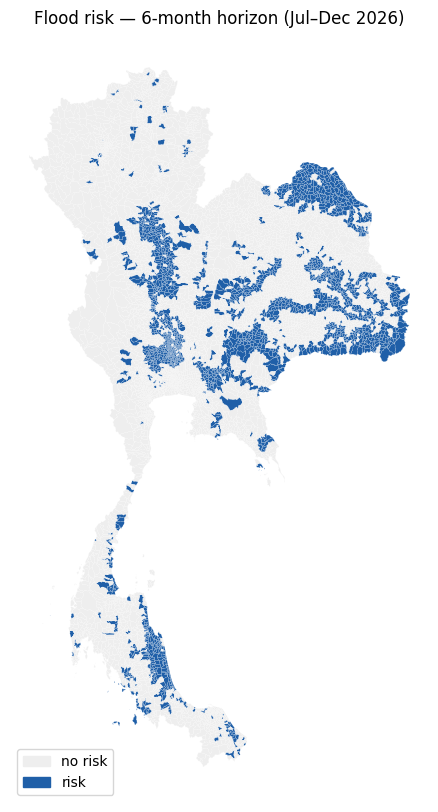

In [52]:
from matplotlib.patches import Patch

FLOOD_COLORS = {'no risk': '#EEEEEE', 'low risk': '#9DC3E6', 'high risk': '#1F5FA8', 'risk': '#1F5FA8'}
FLASH_COLORS = {'no risk': '#EEEEEE', 'low risk': '#F4A582', 'high risk': '#C0261B', 'risk': '#C0261B'}


def plot_risk(layer, colors, title):
    levels_in_layer = [level for level in colors if level in set(layer['RISK_LEVEL'])]
    ax = layer.plot(color=layer['RISK_LEVEL'].map(colors),
                    figsize=(8, 10), edgecolor='white', linewidth=0.1)
    ax.set_title(title)
    ax.axis('off')
    ax.legend(handles=[Patch(color=colors[level], label=level) for level in levels_in_layer],
              loc='lower left')
    return ax


plot_risk(flood_layer, FLOOD_COLORS, 'Flood risk — 6-month horizon (Jul–Dec 2026)')

<Axes: title={'center': 'Flashflood — 6-month horizon (Jul–Dec 2026)'}>

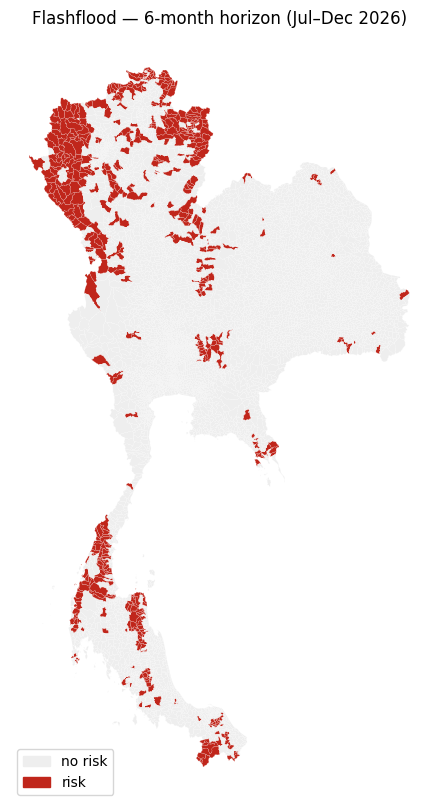

In [53]:
plot_risk(flash_layer, FLASH_COLORS, 'Flashflood — 6-month horizon (Jul–Dec 2026)')

## Output geojson
- one file per type

In [54]:
def save_geojson(layer, path):
    layer.to_file(path, driver='GeoJSON', COORDINATE_PRECISION=8)
    print('Saved', len(layer), 'features to', path, f'({path.stat().st_size / 1e6:.1f} MB)')


save_geojson(flood_layer, OUTPUT_PATH / '202607_flood_risk.geojson')
save_geojson(flash_layer, OUTPUT_PATH / '202607_flashflood_risk.geojson')

Saved 7425 features to /Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/202607_flood_risk.geojson (8.3 MB)
Saved 7425 features to /Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/202607_flashflood_risk.geojson (8.3 MB)
